# MVP Análise de Dados e Boas Práticas

**Nome:** Rafael Henrique da Costa

**Matrícula:** 2026000

**Dataset:** [Iris Dataset](https://archive.ics.uci.edu/dataset/53/iris)

**---OBSERVAÇÕES IMPORTANTES---**

 Encorajamos você a usar a estrutura base deste Notebook para a construção das suas análises, já que ela contempla grande parte das sugestões do checklist no enunciado do MVP. Contudo, vale ressaltar que é necessário realizar mais etapas e análises, além das apresentadas neste notebook. É fundamental ter profundidade nas discussões e análises propostas, construindo um storytelling cativante que explore os principais conceitos e técnicas vistos nas aulas de Análise de Dados e Boas Práticas. **Este bloco de comentário com essas observações deve ser removido do seu projeto final**.

 **------**

# Descrição do Problema

## Descrição do Problema

O naufrágio do RMS Titanic ocorreu em 1912 após a colisão do navio com um iceberg durante sua viagem inaugural. Devido à quantidade limitada de botes salva-vidas disponíveis, muitos passageiros e tripulantes não sobreviveram ao desastre.

O dataset Titanic reúne informações sobre passageiros do navio, incluindo características como idade, sexo, classe da passagem, número de familiares a bordo, tarifa paga e porto de embarque.

A partir dessas informações, o problema consiste em prever se um passageiro sobreviveu ou não ao desastre.

Assim, utilizando técnicas de aprendizado de máquina, busca-se identificar padrões nos dados que expliquem a sobrevivência dos passageiros e permitam prever esse resultado para novos casos com base nas características disponíveis.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Sexo do passageiro e classe da passagem pode influenciar a sobrevivência? Pois historicamente houve prioridade para mulheres, crianças e passageiros de classes mais altas.**

2. **Idade pode influenciar? Pois crianças podem ter recebido prioridade**

3. **Número de familiares a bordo pode ter impactado as chances de sobrevivência?**

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características (comprimento e largura da sépala, comprimento e largura da pétala), o objetivo é prever se uma pessoa iria sobreviver ou não ao naufrágio do Titanic.

## Seleção de Dados

O dataset Iris é um conjunto de dados amplamente disponível e frequentemente incluído em bibliotecas de aprendizado de máquina, como *scikit-learn* no Python. Não é necessária uma etapa de seleção de dados externa, pois o dataset já está curado e pronto para uso.

## Atributos do Dataset

O dataset Titanic contém 891 amostras, com um número variado de sobreviventes e falecidos do desastre. Possui onze atributos:

- ***PassengerId*** (Identificador único de cada passageiro)
- ***Survived*** (Classe de sobrevivência: 0 - Não sobreviveu, 1 - Sobrevivente)
- ***Pclass*** (Classe da passagem: 1 - Primeira classe, 2 - Segunda classe, 3 - terceira classe)
- ***Name*** (Nome do passageiro)
- ***Sex*** (Sexo do passageiro)
- ***Age*** (Idade do passageiro)
- ***SibSp*** (Número de irmãos ou esposos(as) no mesmo barco)
- ***Parch*** (Número de genitores ou filhos no mesmo barco)
- ***Ticket*** (Número do ticket de embarque)
- ***Fare*** (Valor do ticket de embarque)
- ***Embarked*** (Porto no qual o passageiro embarcou)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Titanic - Kaggle.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [22]:
# guardo o dataset em um dataframe
df = pd.read_csv("train.csv")

# alterando o sexo de female para '0' e male para '1' para utilizar na matriz de correlação+
df['Sex'] = df['Sex'].map({"female": 0, "male": 1})

# criando coluna com o número de componentes da família de cada passageiro
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [23]:
# primeiras linhas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,1


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Titanic, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Iris possui 891 instâncias (observações), com instâncias variadas para cada resultado de sobrevivência (0 e 1). As características de medição são de tipo numérico (int ou float), enquanto o atributo 'Survived' é categórico.

In [8]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 891

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(6), object(3)
memory usage: 76.7+ KB
None


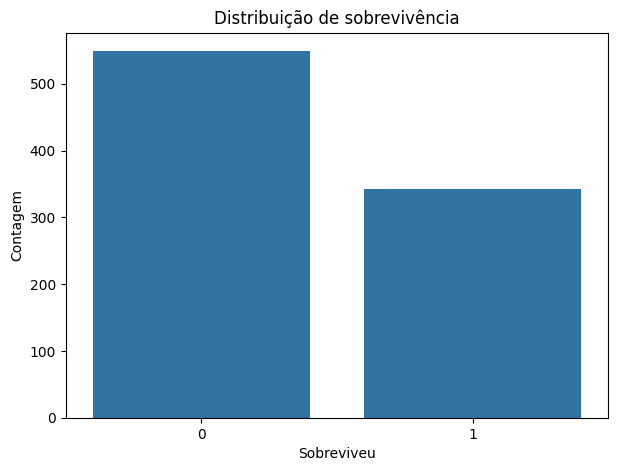

In [ ]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
sns.countplot(x='Survived', data=df)
plt.title('Distribuição de sobrevivência')
plt.xlabel('Sobreviveu')
plt.ylabel('Contagem')
plt.show()

Para analisar a distribuição da variável alvo, foi construído um gráfico de barras representando a frequência das classes da variável Survived, que indica se um passageiro sobreviveu ou não ao desastre do Titanic.

No gráfico, a classe 0 representa os passageiros que não sobreviveram, enquanto a classe 1 representa os passageiros que sobreviveram.

Observa-se que o dataset apresenta desbalanceamento entre as classes, pois o número de passageiros que não sobreviveram é significativamente maior que o número de sobreviventes.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# estatísticas descritivas básicas do dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [6]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
PassengerId,446.000000
Survived,0.383838
Pclass,2.308642
Age,29.699118
SibSp,0.523008
Parch,0.381594
Fare,32.204208


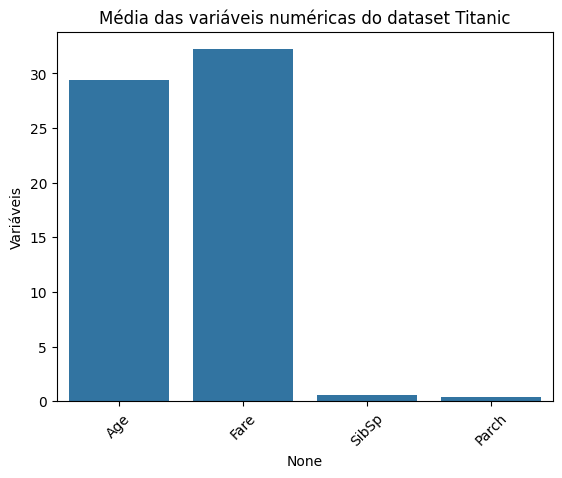

In [9]:
# Qual gráfico seria interessante usar pra mostrar a média?
# Aqui foi utilizado apenas as variáveis numéricas contínuas ou discretas, excluindo as variáveis categóricas como o Pclass por exemplo
dfmean = df[["Age", "Fare", "SibSp", "Parch"]]
means = dfmean.mean()

sns.barplot(x=means.index, y=means.values)

plt.xticks(rotation=45)
plt.title("Média das variáveis numéricas do dataset Titanic")
plt.ylabel("Valor médio")
plt.ylabel("Variáveis")

plt.show()

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [10]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
PassengerId,257.353842
Survived,0.486592
Pclass,0.836071
Sex,0.477990
Age,13.019697
SibSp,1.102743
Parch,0.806057
Fare,49.693429


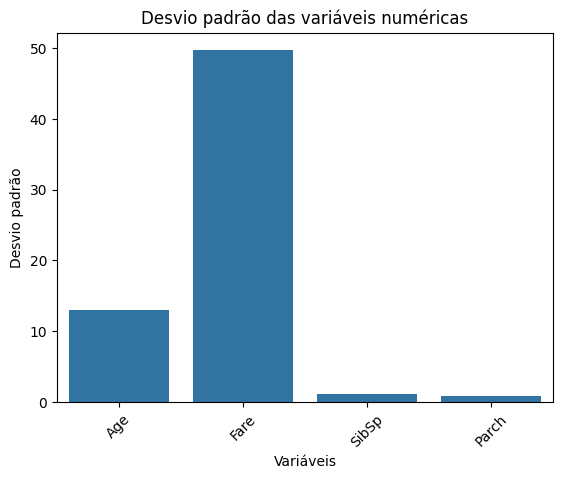

In [11]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?
# Aqui foi utilizado apenas as variáveis numéricas contínuas ou discretas, excluindo as variáveis categóricas como o Pclass por exemplo
dfstd = df[["Age", "Fare", "SibSp", "Parch"]]

std = dfstd.std()

sns.barplot(x=std.index, y=std.values)

plt.xticks(rotation=45)
plt.title("Desvio padrão das variáveis numéricas")
plt.ylabel("Desvio padrão")
plt.xlabel("Variáveis")

plt.show()

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *Idade*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

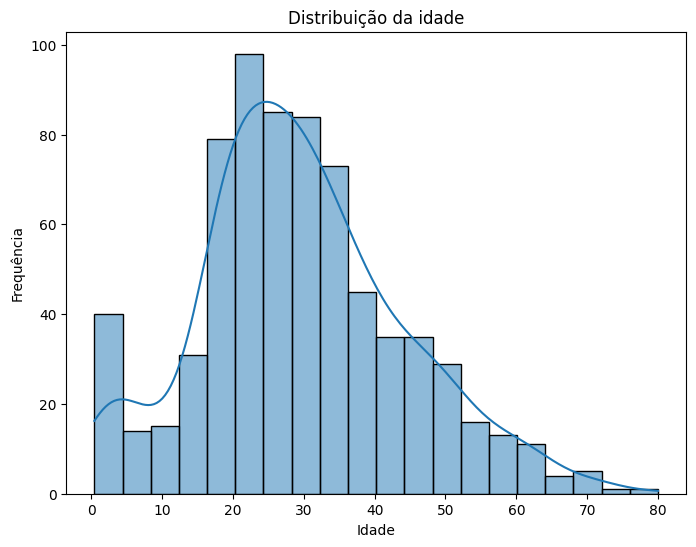

In [10]:
plt.figure(figsize=(8, 6))
# Histograma da idade (um dos atributos)
sns.histplot(df['Age'], kde=True)
plt.title('Distribuição da idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição da idade dos passageiros. A curva de densidade estimada (KDE) nos indica que a distribuição parece unimodal, indicando que a maior parte das idades está concentrada em torno de uma faixa específica (20 a 35 anos).

### *Fare*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

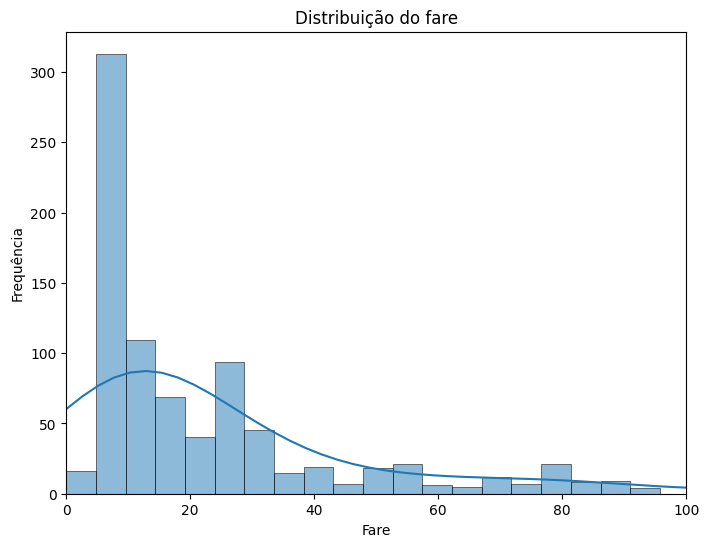

In [15]:
plt.figure(figsize=(8, 6))
# Histograma do fare (um dos atributos)
sns.histplot(df['Fare'], kde=True)
plt.xlim(0, 100)
plt.title('Distribuição do fare')
plt.xlabel('Fare')
plt.ylabel('Frequência')
plt.show()

Quais impressões você tem sobre a distribuição do atributo 'sepal width'?

A análise da distribuição da variável Fare mostra forte concentração de valores aproximadamente entre 5 e 20. Esse padrão sugere que grande parte dos passageiros pagou tarifas relativamente baixas, o que pode indicar predominância de passageiros pertencentes às classes inferiores do navio. No entanto, a tarifa não depende exclusivamente da classe, podendo variar também em função do tipo de cabine ou da compra conjunta de passagens.

## Boxplot

Para entender as diferenças entra as possibilidades de sobrevivência, devemos olhar como se comportam os valores quando agrupadas por estado de sobrevivência. Isso nos permite comparar a média, mediana e desvio padrão de cada resultado, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por espécie
df.groupby('Survived').describe()

PassengerId                                                     \
               count        mean         std  min     25%    50%    75%   
Survived                                                                  
0              549.0  447.016393  260.640469  1.0  211.00  455.0  675.0   
1              342.0  444.368421  252.358840  2.0  250.75  439.5  651.5   

                Pclass            ... Parch        Fare                        \
            max  count      mean  ...   75%  max  count       mean        std   
Survived                          ...                                           
0         891.0  549.0  2.531876  ...   0.0  6.0  549.0  22.117887  31.388207   
1         890.0  342.0  1.950292  ...   1.0  5.0  342.0  48.395408  66.596998   

                                              
          min      25%   50%   75%       max  
Survived                                      
0         0.0   7.8542  10.5  26.0  263.0000  
1         0.0  12.4750  26.0  57.0  512.3292  

[2 rows x 48 columns]

### *petal length* por Espécie


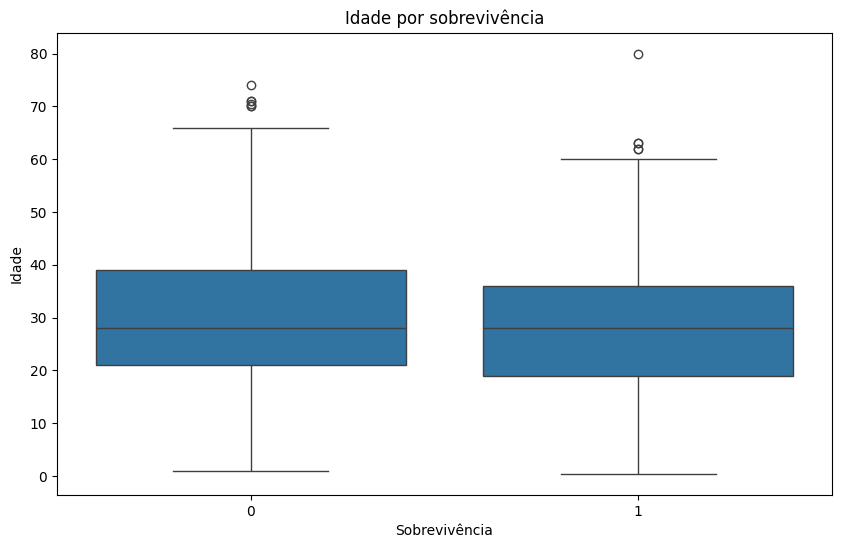

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Idade por sobrevivência')
plt.xlabel('Sobrevivência')
plt.ylabel('Idade')
plt.show()

Foi construído um boxplot relacionando a variável **Age** com a variável **Survived**, com o objetivo de verificar se existe diferença significativa na distribuição das idades entre passageiros que sobreviveram e os que não sobreviveram.

Observa-se que as distribuições são bastante semelhantes, apresentando medianas e intervalos interquartis próximos. Isso indica que, isoladamente, a variável **Age** não parece ser um fator fortemente discriminante para a sobrevivência dos passageiros no dataset analisado.


### *Pclass* por Fare

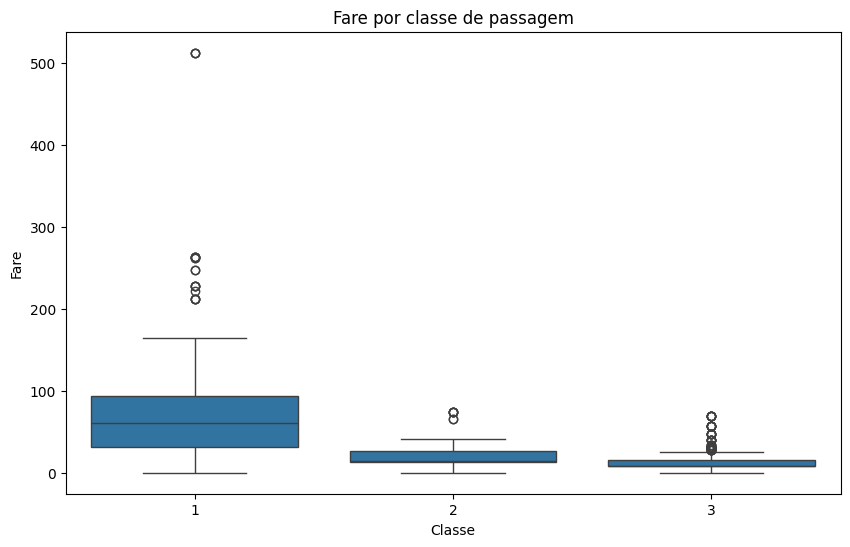

In [12]:
# Boxplot do Fare por classe de passagem
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare por classe de passagem')
plt.xlabel('Classe')
plt.ylabel('Fare')
plt.show()

Quais impressões o boxplot trouxe?

Ao analisar o boxplot da variável **Fare** em função da variável **Pclass**, observa-se que a **primeira classe apresenta uma variação significativamente maior nas tarifas pagas** em comparação com a segunda e a terceira classes. Isso pode ser observado pela maior amplitude da caixa e pela extensão dos valores no gráfico, indicando maior dispersão nos preços das passagens.

Nas classes segunda e terceira, as tarifas encontram-se mais concentradas em intervalos menores, sugerindo menor variação nos preços pagos pelos passageiros dessas categorias.

Além disso, o gráfico revela a presença de **diversos outliers**, especialmente na primeira e na terceira classe. Esses valores extremos indicam passageiros que pagaram tarifas significativamente diferentes da maioria dentro de suas respectivas classes. Isso pode ocorrer por diversos fatores, como diferenças no tipo de cabine, localização no navio, tamanho do grupo que adquiriu a passagem ou outras condições específicas de compra.

Essa análise evidencia que, embora a classe do passageiro esteja relacionada ao valor da tarifa, existe uma **considerável variabilidade nos preços dentro de cada classe**, particularmente na primeira classe.

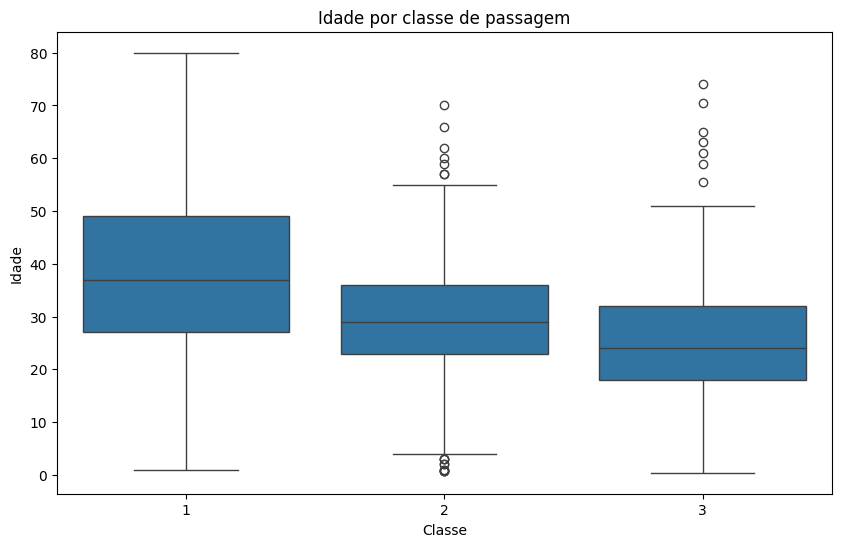

In [5]:
# Boxplot de idade por classe de passagem
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Idade por classe de passagem')
plt.xlabel('Classe')
plt.ylabel('Idade')
plt.show()

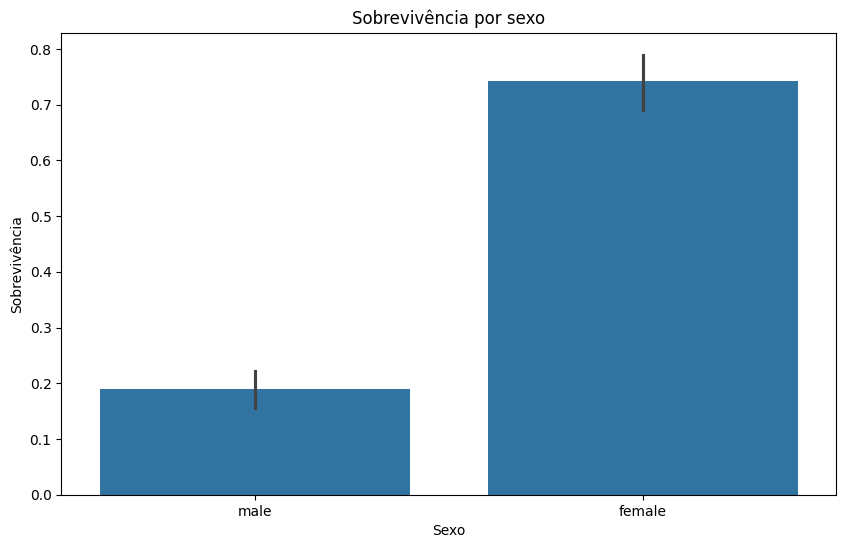

In [9]:
# Barplot sobrevivência por sexo
plt.figure(figsize=(10, 6))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Sobrevivência por sexo')
plt.xlabel('Sexo')
plt.ylabel('Sobrevivência')
plt.show()

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [6]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df.corr(numeric_only=True)


Matriz de Correlação:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.042939,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.543351,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,0.131900,-0.369226,0.083081,0.018443,-0.549500
Sex,0.042939,-0.543351,0.131900,1.000000,0.093254,-0.114631,-0.245489,-0.182333
Age,0.036847,-0.077221,-0.369226,0.093254,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.114631,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.245489,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,-0.182333,0.096067,0.159651,0.216225,1.000000


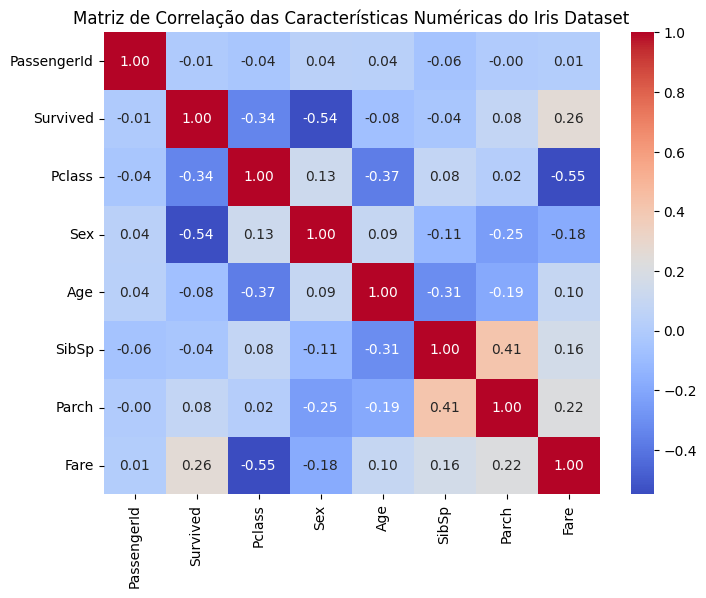

In [7]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Iris Dataset')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [4]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Titanic:")
df.isnull().sum()

Valores nulos no dataset Titanic:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
# Exclusão da coluna 'Cabin' por ausência de mais de 70% dos dados e pela dificuldade de extração de significados úteis
df = df.drop(columns=['Cabin'])

# Preenchimento dos dados faltantes de idade pela mediana da coluna 'Age'
df.fillna({'Age': df['Age'].median()}, inplace=True)

# Preenchimento dos dados faltantes de embarque pela moda da colune 'Embarked'
df.fillna({'Embarked': df['Embarked'].mode()[0]}, inplace=True)

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S


In [7]:
# Verificar a presença de valores nulos após tratamento
print("Valores nulos no dataset Titanic:")
df.isnull().sum()

Valores nulos no dataset Titanic:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [49]:
# Retirar colunas sem utilidade
df = df.drop(columns=['Name', 'Ticket'])

# Separar features (X) e target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

In [50]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [51]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (623, 8)
Dimensões de X_test: (268, 8)
Dimensões de y_train: (623,)
Dimensões de y_test: (268,)


## Normalização

A técnica de normalização (Min-Max Scaling) foi considerada durante a etapa de pré-processamento. Esse método transforma os valores de uma variável para um intervalo fixo, geralmente entre 0 e 1, sendo útil quando diferentes atributos possuem escalas muito distintas.

No entanto, após análise das variáveis do dataset, observou-se que apenas as variáveis **Age** e **Fare** possuem natureza numérica contínua que justificaria algum tipo de transformação de escala. Nesse caso, optou-se por utilizar **padronização (Standardization)** em vez de normalização, pois esse método é mais apropriado para dados que podem apresentar outliers e distribuições assimétricas.

Dessa forma, a normalização Min-Max não foi aplicada ao dataset, sendo substituída pela padronização das variáveis numéricas relevantes.


## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [54]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [64]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train[['Age', 'Fare']])
X_train[['Age', 'Fare']] = scaler_std.transform(X_train[['Age', 'Fare']])
# Usa a média e o desvio padrão aprendidos de X_train
X_test[['Age', 'Fare']] = scaler_std.transform(X_test[['Age', 'Fare']])

In [65]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train, columns=X_train.columns)

In [66]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
     PassengerId  Pclass  Sex       Age  SibSp  Parch      Fare Embarked
748          749       1    1 -0.816093      1      0  0.465738        S
45            46       3    1 -0.126746      0      0 -0.478269        S
28            29       3    0 -0.126746      0      0 -0.481848        Q
633          634       1    1 -0.126746      0      0 -0.646954        S
403          404       3    1 -0.126746      1      0 -0.314823        S


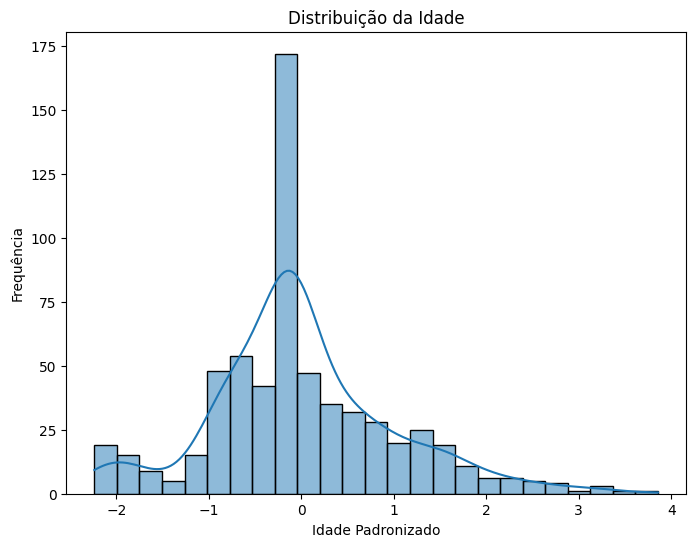

In [68]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Age'], kde=True)
plt.title('Distribuição da Idade')
plt.xlabel('Idade Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

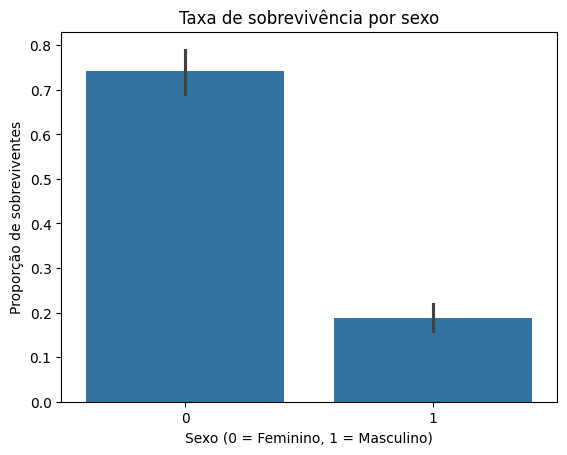

In [19]:
# Sexo do passageiro pode influenciar a sobrevivência? Pois historicamente houve prioridade para mulheres e crianças.

# Barplot de taxa de sobrevivência por sexo
sns.barplot(x='Sex', y='Survived', data=df)

plt.title('Taxa de sobrevivência por sexo')
plt.ylabel('Proporção de sobreviventes')
plt.xlabel('Sexo (0 = Feminino, 1 = Masculino)')
plt.show()

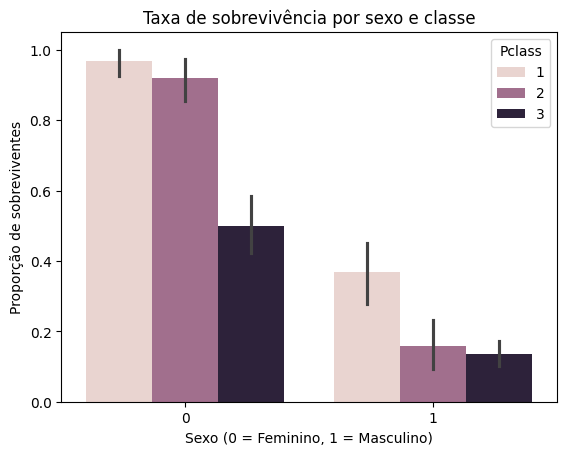

In [21]:
# Barplot de taxa de sobrevivência por sexo e classe
sns.barplot(x="Sex", y="Survived", hue="Pclass", data=df)

plt.title("Taxa de sobrevivência por sexo e classe")
plt.ylabel("Proporção de sobreviventes")
plt.xlabel("Sexo (0 = Feminino, 1 = Masculino)")

plt.show()

Para investigar a hipótese de que o sexo do passageiro influencia a sobrevivência, foi analisada a taxa de sobrevivência por sexo e também a classe do passageiro. O gráfico de barras indica que mulheres apresentaram taxas de sobrevivência significativamente maiores do que homens em todas as classes.

Observa-se também que a classe social teve impacto relevante, uma vez que as mulheres da primeira e segunda classes apresentaram maiores taxas de sobrevivência em comparação com as da terceira classe. Entre os homens, a taxa de sobrevivência foi bastante baixa até mesmo na primeira classe, sendo ainda pior nas demais classes.

In [10]:
# Tabela de contingência

pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
0,81,233
1,468,109


In [11]:
# Tabela de taxa de sobrevivência
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
0,0.742038
1,0.188908


<Axes: xlabel='Sex', ylabel='count'>

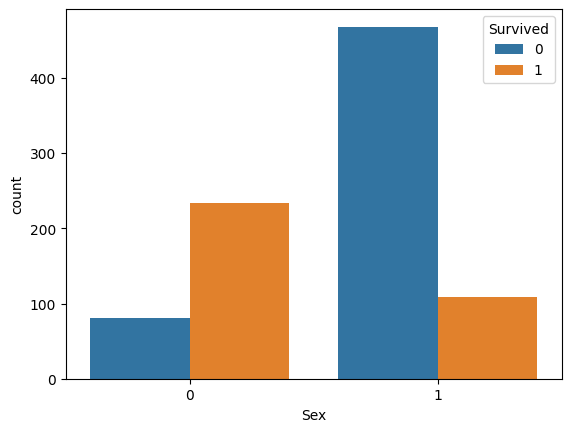

In [12]:
sns.countplot(x='Sex', hue='Survived', data=df)

A análise da relação entre sexo e sobrevivência foi realizada por meio de gráficos e tabelas de frequência. O gráfico de barras da taxa de sobrevivência por sexo indica uma diferença significativa entre homens e mulheres. Observa-se que a proporção de sobrevivência entre mulheres é substancialmente maior do que entre homens. Esse resultado é consistente com o contexto histórico do desastre do RMS Titanic, no qual foi adotada a política de prioridade para mulheres e crianças nos botes salva-vidas.

## Hipótese 2

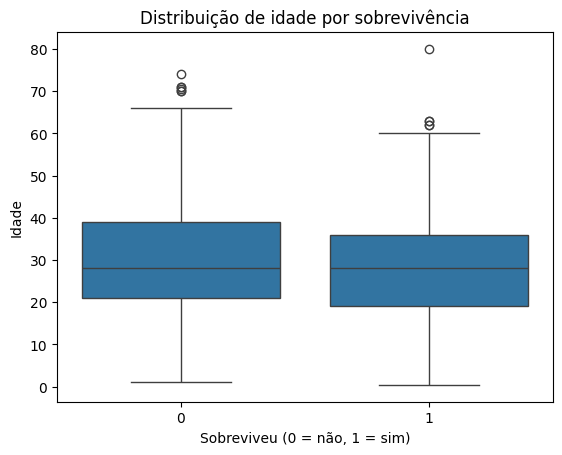

In [14]:
# Idade pode influenciar? Pois crianças podem ter recebido prioridade

# Boxplot de idade por sobrevivência
sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Distribuição de idade por sobrevivência")
plt.xlabel("Sobreviveu (0 = não, 1 = sim)")
plt.ylabel("Idade")

plt.show()

<Axes: xlabel='Age', ylabel='Count'>

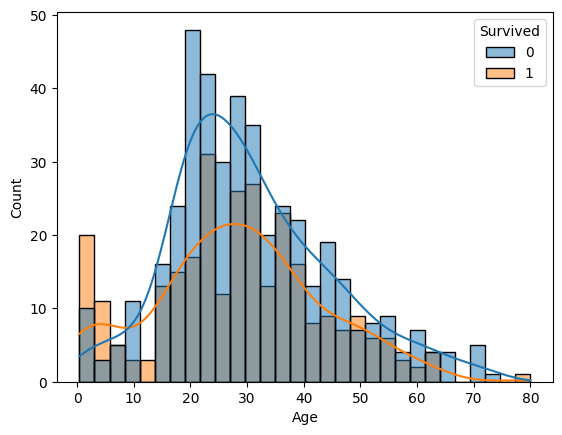

In [15]:
# Histograma separado por sobrevivência
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)

Observa-se que no início do histograma é a única parte onde a linha laranja está por cima da linha azul, indicando que na faixa entre 0 e 10 anos teve mais sobreviventes do que não sobreviventes.

<Axes: xlabel='AgeGroup', ylabel='Survived'>

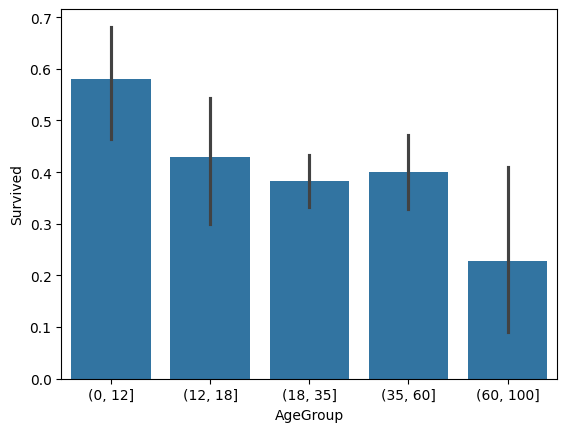

In [16]:
# Barplot com faixas etárias
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100])

sns.barplot(x="AgeGroup", y="Survived", data=df)

Observa-se que o grupo de pessoas entre 0 e 12 anos possuem uma proporção maior de sobrevivência.

In [17]:
# Tabela descritiva útil
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


Para investigar a influência da idade na sobrevivência dos passageiros, foram analisadas as distribuições da variável Age para os grupos de sobreviventes e não sobreviventes. O boxplot e os histogramas indicam que a maioria dos passageiros estava concentrada em faixas etárias adultas. No entanto, observa-se, principalmente no histograma, uma proporção relativamente maior de crianças entre os sobreviventes, o que pode estar relacionado à prioridade dada a mulheres e crianças durante o embarque nos botes salva-vidas.

## Hipótese 3

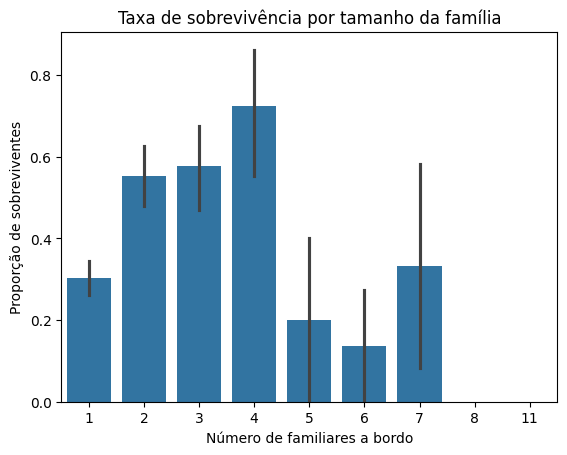

In [24]:
# Número de familiares a bordo pode ter impactado as chances de sobrevivência?

sns.barplot(x="FamilySize", y="Survived", data=df)

plt.title("Taxa de sobrevivência por tamanho da família")
plt.xlabel("Número de familiares a bordo")
plt.ylabel("Proporção de sobreviventes")

plt.show()

<Axes: xlabel='SibSp', ylabel='Survived'>

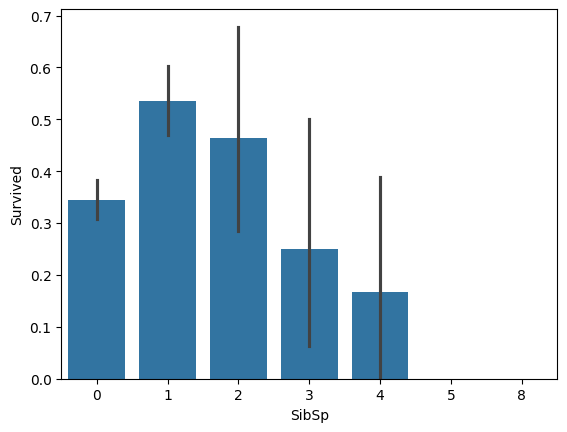

In [25]:
sns.barplot(x="SibSp", y="Survived", data=df)

<Axes: xlabel='Parch', ylabel='Survived'>

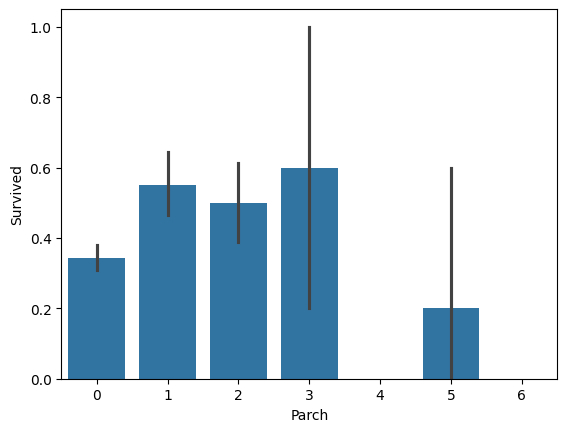

In [26]:
sns.barplot(x="Parch", y="Survived", data=df)

In [27]:
df.groupby("FamilySize")["Survived"].mean()

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


Para investigar a hipótese de que o número de familiares a bordo pode influenciar a sobrevivência, foi criada a variável FamilySize, representando o tamanho da família do passageiro no navio. A análise da taxa de sobrevivência por tamanho de família indica que passageiros que viajavam com famílias pequenas apresentaram maiores taxas de sobrevivência em comparação com aqueles que viajavam sozinhos ou em famílias muito numerosas. Esse padrão sugere que a presença de um pequeno grupo familiar pode ter facilitado a organização e o acesso aos botes salva-vidas durante a evacuação.

# Conclusão

A análise exploratória e o pré-processamento do dataset do Titanic demonstram a importância de compreender a estrutura e as características dos dados antes da aplicação de modelos de aprendizado de máquina. Durante a etapa de análise, foram identificados valores faltantes em algumas variáveis, que foram tratados por meio de estratégias adequadas, como a substituição pela mediana no caso da variável **Age** e pela moda na variável **Embarked**, além da remoção de atributos com grande quantidade de dados ausentes ou pouco informativos, como **Cabin**, **Name** e **Ticket**.

A análise exploratória revelou padrões relevantes no comportamento dos dados. Foi possível observar, por exemplo, que a variável **Fare** apresenta distribuição assimétrica, com grande concentração de valores em faixas de tarifas mais baixas, indicando que muitos passageiros pertenciam às classes inferiores do navio. Também foram identificadas correlações importantes entre algumas variáveis e a sobrevivência dos passageiros, especialmente em relação ao **sexo**, à **classe do passageiro**, à **idade do passageiro** e à **quantidade de familiares à bordo**.

Além disso, foram aplicadas etapas de padronização nas variáveis numéricas contínuas, como **Age** e **Fare**, com o objetivo de ajustar a escala dos dados e preparar o dataset para possíveis algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

As hipóteses levantadas durante a análise foram investigadas e apresentaram evidências nos dados:

**O sexo do passageiro e classe podem influenciar a sobrevivência?**  
Sim. A análise indicou que passageiros do sexo feminino e os de classes mais altas apresentaram taxas de sobrevivência significativamente maiores do que passageiros do sexo masculino e os de classes mais baixas. Esse resultado está de acordo com o contexto histórico do desastre, no qual mulheres e crianças tiveram prioridade no acesso aos botes salva-vidas.

**A idade pode influenciar a sobrevivência?**  
Em certa medida. Embora a distribuição de idades seja relativamente concentrada em adultos, observou-se uma proporção ligeiramente maior de crianças entre os sobreviventes, o que pode estar relacionado à prioridade dada a crianças durante a evacuação.

**O número de familiares a bordo pode impactar as chances de sobrevivência?**  
Os resultados sugerem que passageiros que viajavam com famílias pequenas apresentaram taxas de sobrevivência relativamente maiores em comparação com aqueles que viajavam sozinhos ou em grupos familiares muito grandes. Isso pode indicar que pequenos grupos familiares poderiam facilitar a organização e a evacuação durante o desastre.

De maneira geral, a análise demonstrou que fatores sociais e demográficos, como **sexo**, **classe do passageiro** e **estrutura familiar**, tiveram papel importante nas chances de sobrevivência dos passageiros do Titanic. Esses resultados evidenciam como a análise exploratória de dados pode revelar padrões relevantes antes da aplicação de modelos preditivos.